# Rolling Up, Looking Back
## Objective
You’ve been given a table with raw data for individual coffee shop transactions. Your task is to aggregate the total sales by month and store, then calculate the month-over-month change in sales for each store (in dollars).

[[Source]](https://mavenanalytics.io/data-drills/rolling-up-looking-back)

In [75]:
import pandas as pd

file = pd.read_csv("coffee_shop_sales.csv", parse_dates=["date"])

file.head(2)

,order_id,date,store,product,quantity,sales
0,1,2023-01-01,Lower Manhattan,Gourmet brewed coffee,2,6.0
1,2,2023-01-01,Lower Manhattan,Brewed Chai tea,2,6.2


In [84]:
file["month"] = file["date"].dt.month

month = (file
         .groupby(["store", file["date"].dt.month])
         .agg({"sales": "sum"})
         .rename({"dale": "month"})
         .reset_index())
month["diff"] = month.groupby("store")["sales"].diff()
month.fillna(0)

,store,date,sales,diff
0,Astoria,1,27313.66,0.00
1,Astoria,2,25105.34,-2208.32
2,Astoria,3,32835.43,7730.09
3,Astoria,4,39477.61,6642.18
4,Astoria,5,52428.76,12951.15
5,Astoria,6,55083.11,2654.35
6,Hell's Kitchen,1,27820.65,0.00
7,Hell's Kitchen,2,25719.80,-2100.85
8,Hell's Kitchen,3,33110.57,7390.77
9,Hell's Kitchen,4,40304.14,7193.57


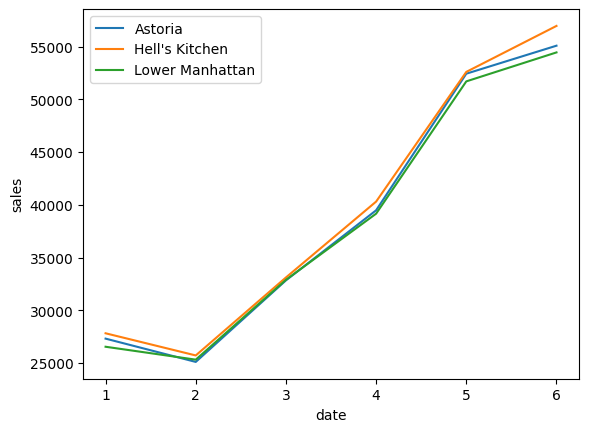

In [104]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.lineplot(data=month, x="date", y="sales", hue="store")


plt.legend()
plt.show()

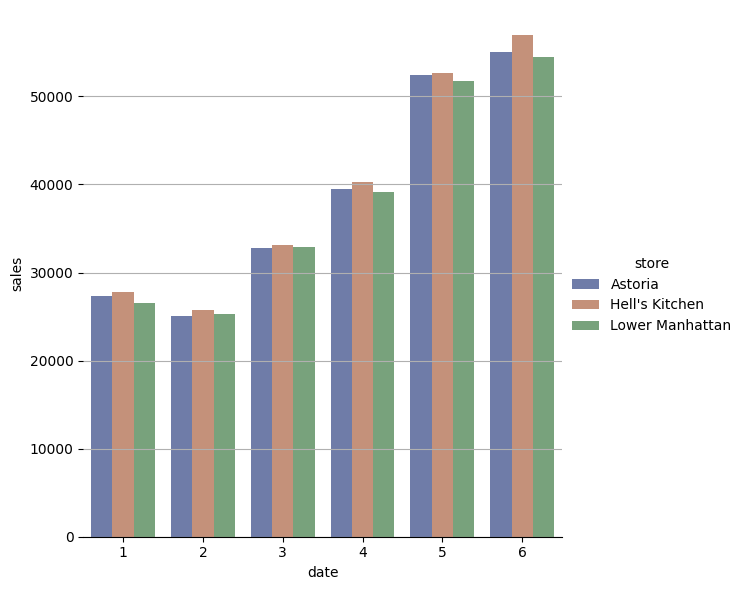

In [113]:
sns.catplot(data=month, x="date", y="sales", hue= "store", 
            kind="bar", palette="dark", errorbar="sd",  
            height=6, alpha=.6).despine(left=True).ax.yaxis.grid(True)
plt.show()

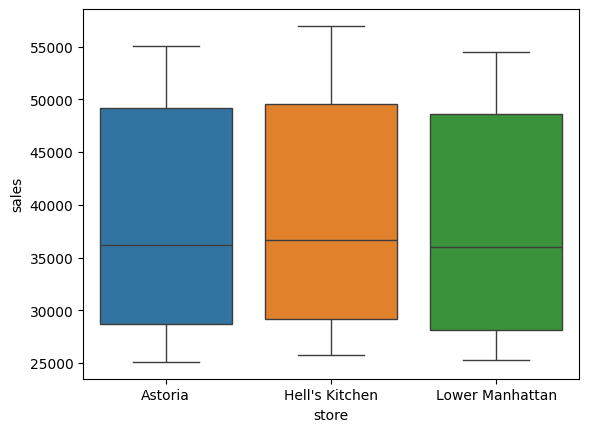

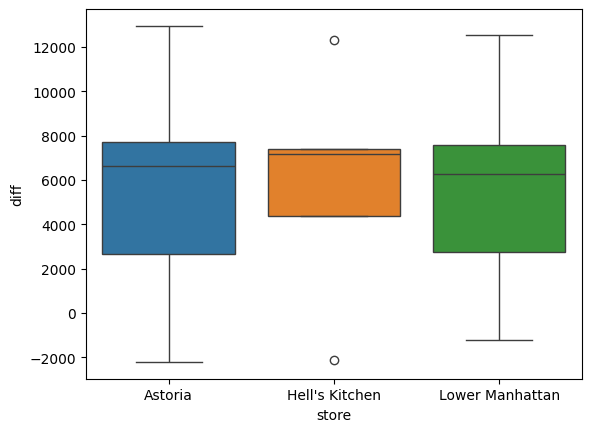

In [95]:

sns.boxplot(data=month, x="store", y="sales", hue= "store")
plt.show()
sns.boxplot(data=month, x="store", y="diff", hue= "store")
plt.show()